# **Project**: **Food Delivery Data Analysis and Preprocessing**

### Objective:

Prepare and clean the food delivery dataset for further analysis, focusing on data quality, anomaly detection, and normalization.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### **Tasks:**

### Importing Libraries

In [ ]:
# import libraries for data manipulation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import libraries for data visualization



### Understanding the structure of the data

 Load the dataset and perform initial exploration

In [ ]:
# Load the dataset using read_csv
data = (pd.read_csv('foodhub_order.csv'))

# Display the first few rows of the dataset
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [ ]:
data.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


In [ ]:
numerical_data = data.select_dtypes(include=np.number)

# Perform aggregation on numerical_data
aggregated_data = numerical_data.aggregate(['min', 'max', 'mean', 'median'])

# Display the aggregated data
aggregated_data

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
min,1476547.0,1311.000000,4.470000,20.00000,15.000000
max,1478444.0,405334.000000,35.410000,35.00000,33.000000
mean,1477495.5,171168.478398,16.498851,27.37197,24.161749
median,1477495.5,128600.000000,14.140000,27.00000,25.000000


### **Question 1:** How many rows and columns are present in the data?

In [ ]:
print('Number of rows:', data.shape[0])
print('Number of columns:',data.shape[1])

Number of rows: 1898
Number of columns: 9


### **Question 2a:** What are the datatypes of the different columns in the dataset? (The info() function can be used)

In [ ]:
type(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


NoneType

### **Question 2b**: Classify each column into the following categories:

**Qualitative (Categorical)**:
- Nominal: Variables with no inherent order
- Ordinal: Variables with a meaningful order

**Quantitative (Numerical):**
- Discrete: Countable, integer values
- Continuous: Measurable, can take any value within a range

In [ ]:
# prompt: classify each column into categorical and numerical categories

# Qualitative (Categorical)
# Nominal: order_id, customer_id, restaurant_name, cuisine_type, day_of_the_week
# Ordinal: rating

# Quantitative (Numerical)
# Discrete:  None (Although cost, food_preparation_time, and delivery_time are represented as numbers, they are likely discrete given the context)
# Continuous: cost, food_preparation_time, delivery_time

In [ ]:
data.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


## **Data Cleaning and Preprocessing**

a.  **Handle missing values**:

### **Question 3a:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [ ]:
# prompt: Are there any missing values in the data? If yes, treat them using an appropriate method

# Check for missing values
print(data.isnull().sum())

# Impute missing values in 'cost', 'food_preparation_time', and 'delivery_time' with the median
for col in ['cost', 'food_preparation_time', 'delivery_time']:
    data[col].fillna(data[col].median(), inplace=True)

# For categorical features like 'rating', imputation might not be suitable.  You can choose to remove rows with missing ratings, or replace missing values with the most frequent value (mode) or a designated category ("Unknown").
# Example using mode:
data['rating'].fillna(data['rating'].mode()[0], inplace=True)


#Verify if missing values are handled
print(data.isnull().sum())

In [ ]:
print(data.isna().sum())

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


### **Question 3b**: Are there any data mismatch?, If yes, treat them appropriately

In [ ]:

data['rating'] = data['rating'].astype('category')

### **Question 3c**: Are there any duplicates?

In [ ]:
 data.duplicated().sum()

0

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed?

In [ ]:
food_preparation_time_stats = data['food_preparation_time'].describe()
print(food_preparation_time_stats)

count    1898.000000
mean       27.371970
std         4.632481
min        20.000000
25%        23.000000
50%        27.000000
75%        31.000000
max        35.000000
Name: food_preparation_time, dtype: float64


In [ ]:
delivery_time_stats = data['delivery_time'].describe()
print(delivery_time_stats)

count    1898.000000
mean       24.161749
std         4.972637
min        15.000000
25%        20.000000
50%        25.000000
75%        28.000000
max        33.000000
Name: delivery_time, dtype: float64


In [ ]:
cost_of_the_order_stats = data['cost_of_the_order'].describe()
print(cost_of_the_order_stats)

count    1898.000000
mean       16.498851
std         7.483812
min         4.470000
25%        12.080000
50%        14.140000
75%        22.297500
max        35.410000
Name: cost_of_the_order, dtype: float64


### Exploratory Data Analysis (EDA)
### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration)

Text(0.5, 1.0, 'Distribution of Delivery Time')

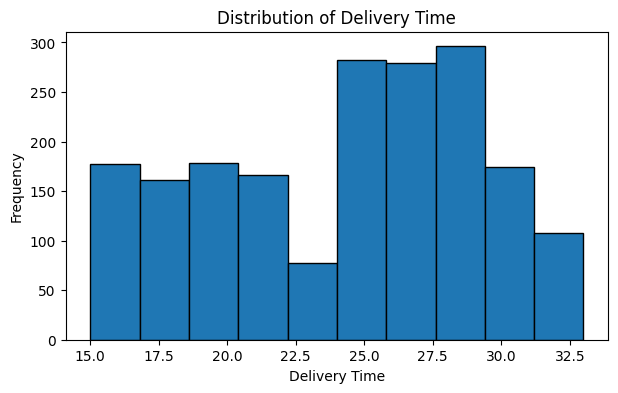

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(data= data, x='delivery_time' ,edgecolor='black')
plt.xlabel('Delivery Time')
plt.ylabel('Frequency')
plt.title('Distribution of Delivery Time')

Text(0.5, 1.0, 'Distribution of food prep time')

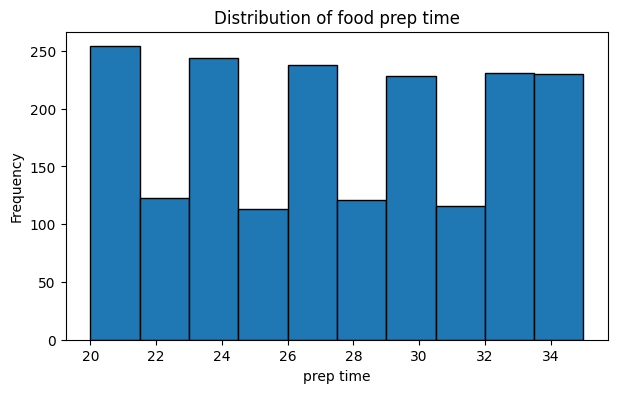

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(data= data, x='food_preparation_time' ,edgecolor='black')
plt.xlabel('prep time')
plt.ylabel('Frequency')
plt.title('Distribution of food prep time')

---
---
## **Identify potential outliers in numerical column**s:
- Use box plots or z-scores for `cost`, `food_preparation_time`, and `delivery_time`
-
Discuss any patterns or insights from the outliers

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received?

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
                            ... 
Sushi Choshi                   1
Dos Caminos Soho               1
La Follia                      1
Philippe Chow                  1
'wichcraft                     1
Name: count, Length: 178, dtype: int64


Text(0.5, 1.0, 'Top 5 Restaurants by Number of Orders')

/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 142 (\x8e) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 140 (\x8c) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 142 (\x8e) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 140 (\x8c) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


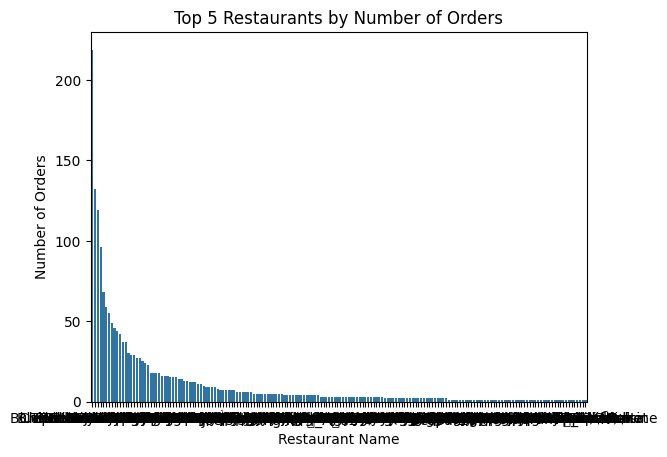

In [ ]:
restaurant_count = data['restaurant_name'].value_counts()
print(restaurant_count)
sns.barplot(x=restaurant_count.index, y=restaurant_count.values)
plt.xlabel('Restaurant Name')
plt.ylabel('Number of Orders')
plt.title('Top 5 Restaurants by Number of Orders')

### **Question 8**: Which is the most popular cuisine on weekends?

### **Question 10**: What is the mean order delivery time?